In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

In [48]:
df = pd.read_csv("/cleaned_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day_name()
df['fraud_label_str'] = df['fraud_label'].map({0: 'Legit', 1: 'Fraud'})

In [49]:
print("Shape of dataset:", df.shape)
print("\nColumn names and data types:")
print(df.dtypes)

print("\nFirst few rows of the dataset:")
display(df.head())

Shape of dataset: (47740, 22)

Column names and data types:
transaction_amount                     float64
transaction_type                        object
timestamp                       datetime64[ns]
account_balance                        float64
device_type                             object
location                                object
merchant_category                       object
ip_address_flag                          int64
previous_fraudulent_activity             int64
daily_transaction_count                  int64
avg_transaction_amount_7d              float64
failed_transaction_count_7d              int64
card_type                               object
card_age                                 int64
transaction_distance                   float64
authentication_method                   object
risk_score                             float64
is_weekend                               int64
fraud_label                              int64
hour                                     int32


,transaction_amount,transaction_type,timestamp,account_balance,device_type,location,merchant_category,ip_address_flag,previous_fraudulent_activity,daily_transaction_count,...,card_type,card_age,transaction_distance,authentication_method,risk_score,is_weekend,fraud_label,hour,day,fraud_label_str
0,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,0,7,...,Amex,65,883.17,Biometric,0.8494,0,0,19,Monday,Legit
1,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,0,13,...,Mastercard,186,2203.36,Password,0.0959,0,1,4,Wednesday,Fraud
2,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,0,14,...,Visa,226,1909.29,Biometric,0.8400,0,1,15,Tuesday,Fraud
3,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,0,8,...,Visa,76,1311.86,OTP,0.7935,0,1,0,Thursday,Fraud
4,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,1,14,...,Mastercard,140,966.98,Password,0.3819,1,1,23,Saturday,Fraud


<ipython-input-62-73c32263361f>:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




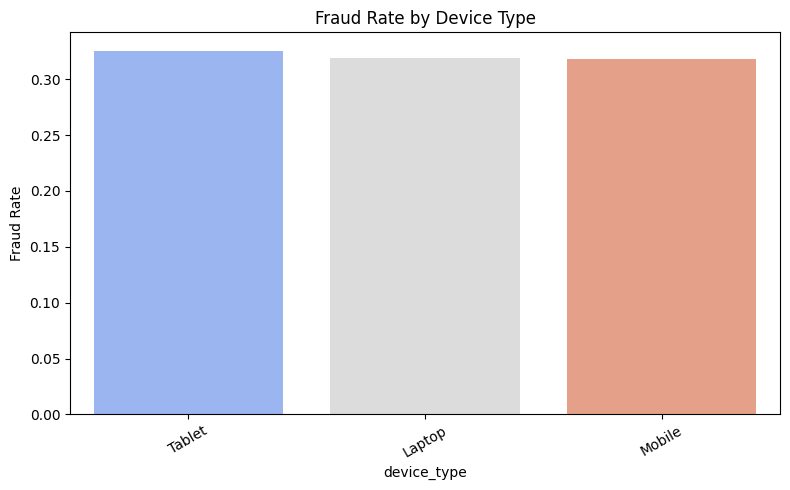

<ipython-input-62-73c32263361f>:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




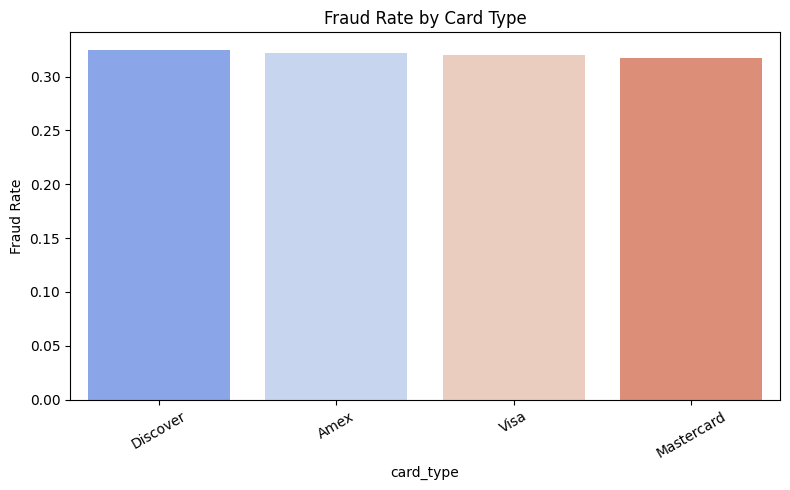

In [62]:
# Fraud Rate by Category (Composite Plot)

cat_features = ['device_type', 'card_type']
for feature in cat_features:
    fraud_rate = df.groupby(feature)['fraud_label'].mean().sort_values(ascending=False).reset_index()
    plt.figure(figsize=(8,5))
    sns.barplot(data=fraud_rate, x=feature, y='fraud_label', palette='coolwarm')
    plt.title(f'Fraud Rate by {feature.replace("_", " ").title()}')
    plt.ylabel("Fraud Rate")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

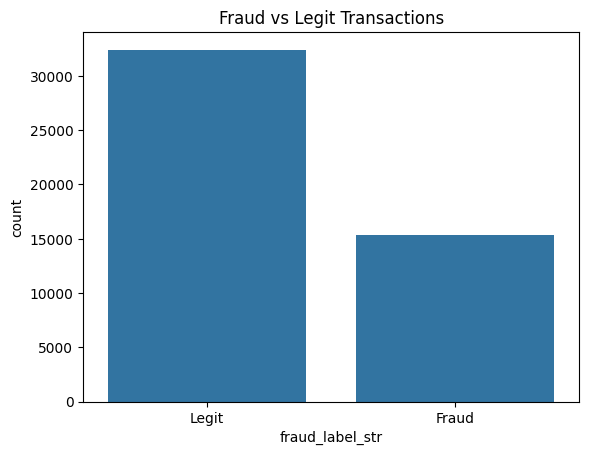

In [50]:
# 1. Fraud Distribution

sns.countplot(x='fraud_label_str', data=df)
plt.title('Fraud vs Legit Transactions')
plt.show()

To start our analysis, we wanted to understand the basic composition of our dataset — especially the proportion of fraudulent to legitimate transactions.

We created a **count plot** using the `fraud_label_str` column, which we derived from the original `fraud_label` field. This plot visually compares the total number of fraudulent (`Fraud`) and non-fraudulent (`Legit`) transactions.

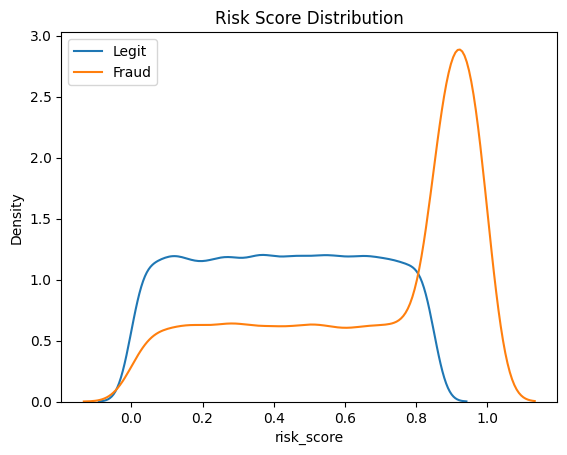

In [51]:
# 2. Risk Score Distribution

df['risk_score'] = pd.to_numeric(df['risk_score'], errors='coerce')
df = df.dropna(subset=['risk_score'])
sns.kdeplot(data=df[df.fraud_label == 0], x='risk_score', label='Legit')
sns.kdeplot(data=df[df.fraud_label == 1], x='risk_score', label='Fraud')
plt.title("Risk Score Distribution")
plt.legend()
plt.show()

One of the key features in this dataset is the `risk_score`, which is likely generated by a model to represent how suspicious a transaction is (closer to 1 = high risk).

We plotted the **distribution of risk scores** for both fraud and legit transactions using a KDE (Kernel Density Estimate) plot.

#### What we saw:
- Fraudulent transactions (orange) are highly concentrated around **very high risk scores (~0.9–1.0)**.
- Legit transactions (blue) are spread more evenly, but tend to fall below **0.8**.
- There’s a clear shift in the shape of the two curves — this tells us that `risk_score` is doing its job: **separating fraud from non-fraud.**

This was one of the few features that showed a strong signal and helped us understand how **model-generated features (like risk_score) can be far more discriminative** than raw transaction values.

This plot helped validate that the `risk_score` feature is **trustworthy and meaningful**, and should be prioritized in any future predictive modeling or dashboard design.

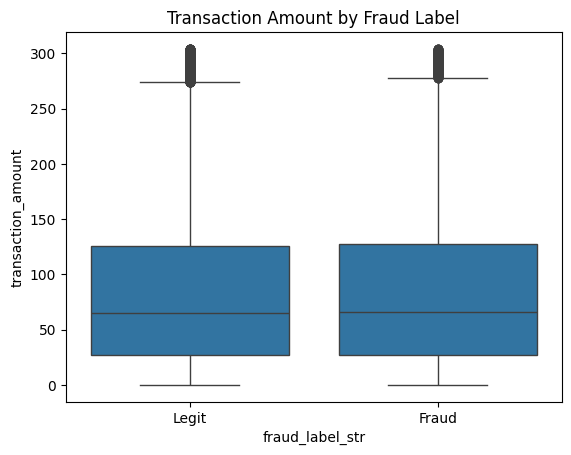

In [52]:
# 3. Transaction Amount vs Fraud (Boxplot)

sns.boxplot(data=df, x='fraud_label_str', y='transaction_amount')
plt.title("Transaction Amount by Fraud Label")
plt.show()

### We didnt like this particular box plot. Too many points are overlapping and we also have extreme outliners. So we figured out that maybe violin + box plot might help solve this issue.

<ipython-input-53-74a491a4fd27>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




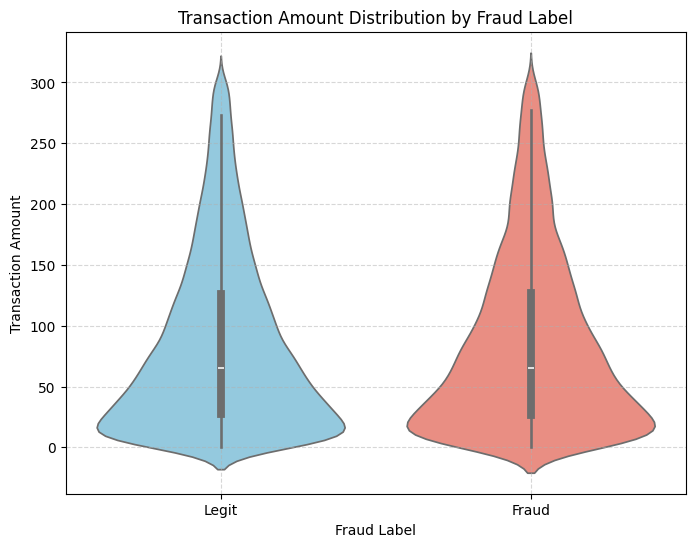

In [53]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='fraud_label_str', y='transaction_amount', palette=['skyblue', 'salmon'], inner='box')
plt.title("Transaction Amount Distribution by Fraud Label")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Amount")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

We used a violin plot to compare how transaction amounts are distributed for fraud and legit transactions. At first, we expected that fraudulent transactions would be consistently higher or lower in value. But the plot shows that both legit and fraud transactions cover a **very similar range** of amounts.

- The distribution shape is almost the same for both classes.
- Most transactions (fraud or not) are between **0 and 150 units**.
- There are **some outliers** on both sides (closer to 300+), but no strong difference in the center or spread.

From this, we realized that **transaction amount by itself doesn’t clearly separate fraud from legit** in this dataset. So, we shouldn’t rely on it alone for prediction — it’s better used in combination with other features like `risk_score`, `distance`, or user behavior over time.

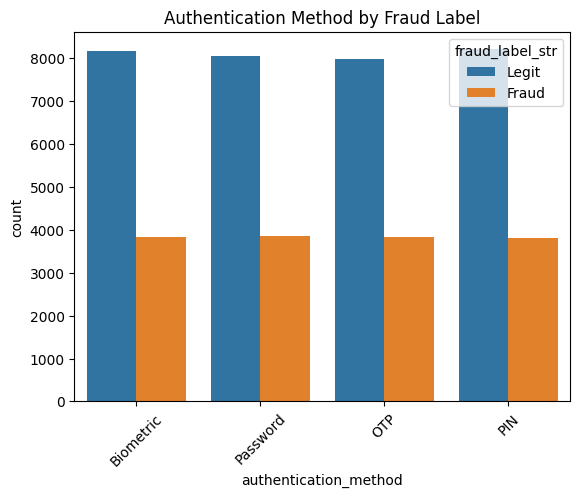

In [54]:
# 4. Authentication Method vs Fraud

sns.countplot(data=df, x='authentication_method', hue='fraud_label_str')
plt.title("Authentication Method by Fraud Label")
plt.xticks(rotation=45)
plt.show()

I couldn’t understand anything specifically using this count plot. We thought it could provide us with the information regarding authentication method vs fraud. So, we thought of plotting a simple fraud rate bar chart for each authentication method instead. This allowed us to normalize for the total number of transactions per method and get a clearer comparison.

<ipython-input-55-7c0cbab53e8a>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




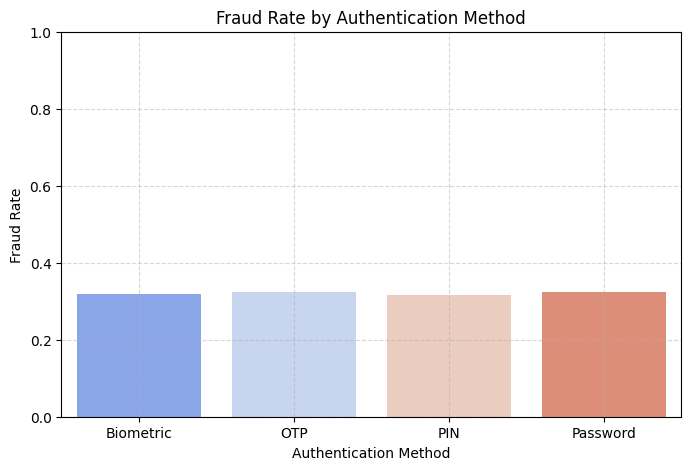

In [55]:
fraud_rate = df.groupby('authentication_method')['fraud_label'].mean().reset_index()
fraud_rate.columns = ['Authentication Method', 'Fraud Rate']

plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_rate, x='Authentication Method', y='Fraud Rate', palette='coolwarm')
plt.title("Fraud Rate by Authentication Method")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### However, the fraud rates turned out to be almost identical across all authentication methods, suggesting that authentication type alone may not play a significant role in determining fraud in this dataset (it is mostly balanced throughout the dataset). This prompted us to shift focus to more discriminative features like risk score, transaction distance, and time of transaction.

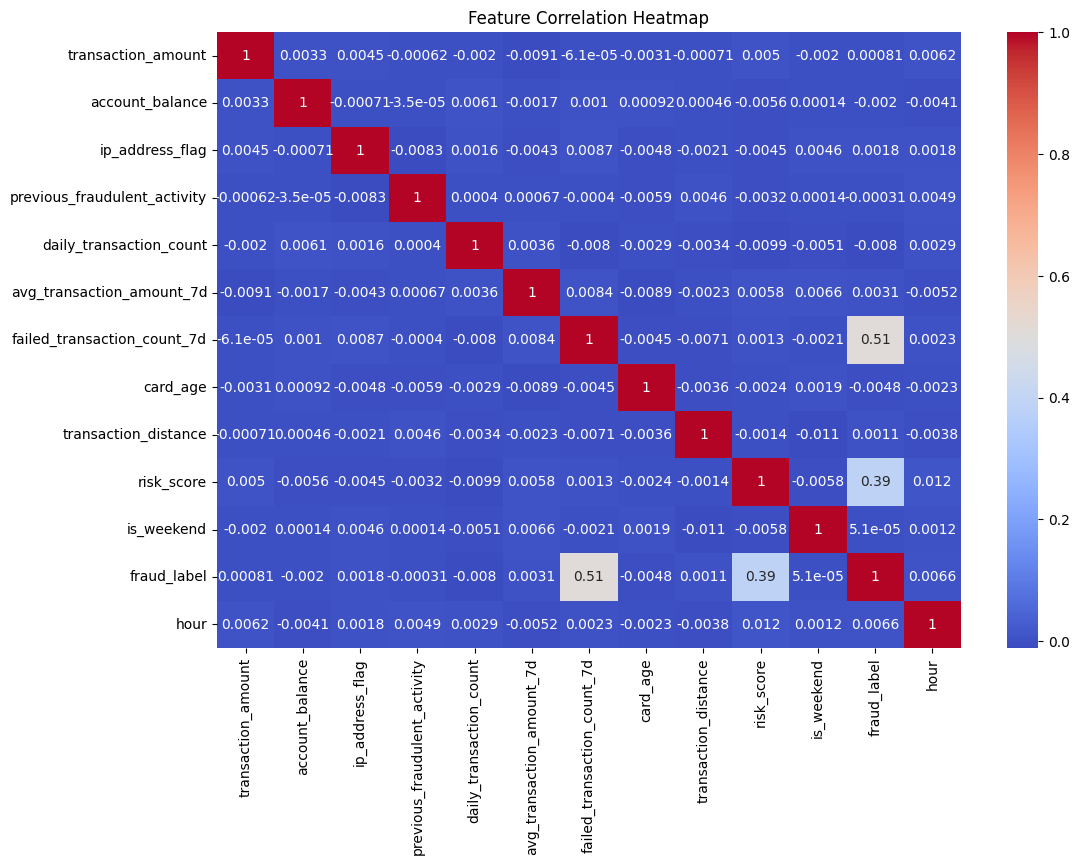

In [56]:
# 5. Correlation Heatmap

numeric_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_features.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap helps identify relationships between numerical features and the fraud label.

- Most features show **very low correlation** with each other and with the fraud label, indicating that no single variable is strongly predictive on its own.
- `failed_transaction_count_7d` shows a **moderate positive correlation (~0.51)** with `fraud_label`, suggesting that users who have more failed transactions in the past 7 days are more likely to commit fraud.
- `risk_score` also shows a **positive correlation (~0.39)** with fraud, aligning with expectations — higher risk scores correspond to a greater likelihood of fraudulent behavior.
- Other features like `transaction_amount`, `account_balance`, `transaction_distance`, and `hour` have **very weak correlations** with fraud.

These insights suggest that **temporal behavior and historical failure patterns** are more indicative of fraud than one-time transaction characteristics.

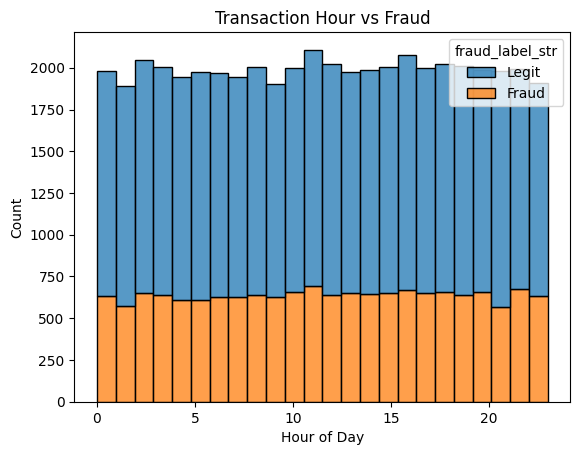

In [57]:
# 6. Hourly Fraud Trend

sns.histplot(data=df, x='hour', hue='fraud_label_str', bins=24, multiple='stack')
plt.title("Transaction Hour vs Fraud")
plt.xlabel("Hour of Day")
plt.show()

We initially expected that fraud might spike during late-night hours when fewer transactions are being monitored. However, after plotting the transaction count by hour (split by fraud and legit), we noticed that the distribution is quite even throughout the day.

There wasn’t any particular hour that stood out with significantly higher fraud. Although we see slightly more overall activity between 10 AM and 2 PM, both fraud and legit transactions follow a similar pattern.

This made us realize that **time of day by itself may not be a strong factor in detecting fraud** in this dataset. We'll need to combine it with other behavioral indicators like risk score or transaction type to get better insights.

In [58]:
# 7. Sankey Diagram

sankey_df = df.groupby(['transaction_type', 'authentication_method', 'fraud_label']).size().reset_index(name='count')
sankey_df['fraud_label_str'] = sankey_df['fraud_label'].map({0: 'Legit', 1: 'Fraud'})
labels = pd.unique(sankey_df[['transaction_type', 'authentication_method', 'fraud_label_str']].values.ravel())
label_map = {label: i for i, label in enumerate(labels)}

sources1 = sankey_df['transaction_type'].map(label_map)
targets1 = sankey_df['authentication_method'].map(label_map)
values1 = sankey_df['count']

sources2 = sankey_df['authentication_method'].map(label_map)
targets2 = sankey_df['fraud_label_str'].map(label_map)
values2 = sankey_df['count']

fig = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=list(label_map.keys())),
    link=dict(
        source=pd.concat([sources1, sources2]),
        target=pd.concat([targets1, targets2]),
        value=pd.concat([values1, values2])
    )
)])
fig.update_layout(title_text="Transaction Type → Auth Method → Fraud", font_size=10)
fig.show()

We used a Sankey diagram to visualize the flow of transactions across three stages: the **transaction type**, the **authentication method used**, and the final **fraud outcome**.

Our goal was to identify which pathways were most associated with fraud.

- We observed that all transaction types (Online, POS, ATM Withdrawals, Bank Transfers) flow fairly evenly into different authentication methods.
- Across all flows, **Password** and **PIN** authentication showed noticeable connections to fraudulent outcomes — but the differences weren’t extreme.
- **Biometric** and **OTP-based** transactions tended to end more frequently in `Legit`, which might indicate they are slightly more secure in this dataset.

From this, we realized that while the diagram is visually helpful for showing volume, it didn’t reveal one very clear fraud-prone path. So we concluded that **authentication method and transaction type individually are not strong fraud predictors**, but could still be useful when combined with other features like `risk_score`.

This was a fun visual to experiment with and helped us think in terms of **flows**, rather than just individual features.

## *After trying all sorts of visuaizations and analysising the trends, we came to a conclusion that no single/individual alone is a major factor. So, we then asked ourselves:*

1. ## **What features most influence the risk score?**

2. ## **Can we group users based on behavioral profiles?**

3. ## **Which transactions look normal but end in fraud?**

<ipython-input-59-60cd00e1ec50>:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




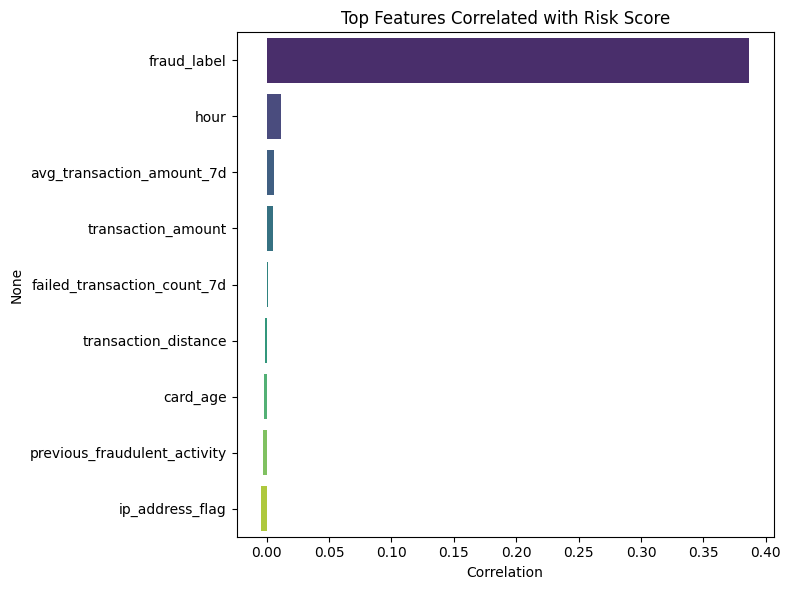

In [59]:
# Correlation of Features with Risk Score

numeric = df.select_dtypes(include=np.number)
correlation = numeric.corr()['risk_score'].sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=correlation.values[1:10], y=correlation.index[1:10], palette='viridis')
plt.title("Top Features Correlated with Risk Score")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

We wanted to understand which features influence the `risk_score` — since it’s a key signal for fraud detection. So we calculated and plotted the correlation of each numeric feature with the risk score.

- Surprisingly, `fraud_label` itself had the highest correlation (~0.39), which makes sense because risk score is likely built to predict fraud.
- However, all other features showed **very weak correlations** with risk score — most were close to 0.
- Even features like `failed_transaction_count_7d`, `transaction_amount`, and `previous_fraudulent_activity` showed **no strong linear relationship**.

This tells us that **risk_score might be calculated from complex patterns** or hidden interactions between features — not just simple linear relationships. So, we moved toward techniques like **PCA and clustering** to explore deeper patterns in user behavior.

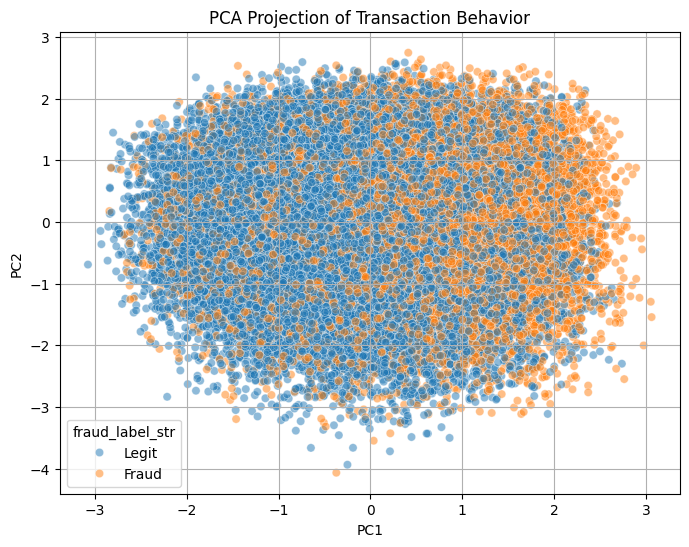

In [60]:
# PCA Visualization of Transaction Behavior

import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

features = ['transaction_amount', 'account_balance', 'daily_transaction_count',
            'avg_transaction_amount_7d', 'transaction_distance', 'risk_score']

scaled = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=2)
components = pca.fit_transform(scaled)
df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='fraud_label_str', alpha=0.5)
plt.title("PCA Projection of Transaction Behavior")
plt.grid(True)
plt.show()

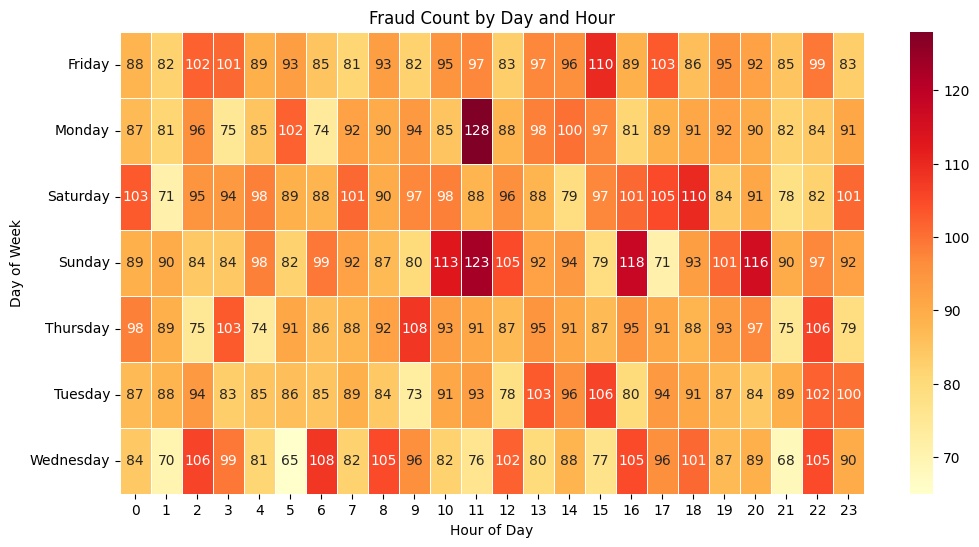

In [61]:
# Time-Based Heatmap: Day vs Hour vs Fraud Count

time_df = df.groupby(['day', 'hour'])['fraud_label'].sum().reset_index()
time_pivot = time_df.pivot(index='day', columns='hour', values='fraud_label')
plt.figure(figsize=(12,6))
sns.heatmap(time_pivot, cmap='YlOrRd', linewidths=0.5, annot=True, fmt='.0f')
plt.title("Fraud Count by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

We created this heatmap to explore whether certain hours or days of the week had higher fraud activity.

- The colors represent the number of fraudulent transactions for each hour of each day.
- While fraud occurs fairly consistently across the entire week, we noticed a few patterns:
  - **Midday (around 11 AM to 2 PM)** tends to show slightly higher fraud counts.
  - **Monday and Sunday** show occasional spikes — like Monday at 11 AM (128 frauds) and Sunday late afternoon.
  - **Early morning (2 AM – 6 AM)** tends to have lower fraud activity overall.

Even though there’s no huge spike on a specific day or time, this plot helped us realize that **fraud doesn’t randomly occur — it clusters more around general high-activity hours**.

If we had user or merchant context, we could explore whether these spikes align with shift changes, business hours, or transaction load.

### When we chose to work on banking fraud detection using visual analytics, we were curious to see if fraudulent transactions could be identified just by exploring patterns in the data. We expected clear visual distinctions — perhaps certain times of day, transaction types, or risk scores standing out sharply between fraud and legit cases.

### What we found instead was much more real: **fraud is designed to blend in.** Our visualizations — PCA, clustering, correlation heatmaps, and time-based breakdowns — consistently showed that fraud rarely reveals itself through a single feature or simple plot.

### And that’s the point.

### This project helped us realize that fraud detection isn’t about “catching the obvious.” It’s about uncovering **subtle, behavioral clues** spread across time, user context, and system signals. While visual EDA didn’t give us dramatic results, it taught us **where not to look**, and which features hold enough signal to justify modeling.

### We believe this is a valuable lesson — not just in analytics, but in developing the mindset of a real data scientist. That’s why we’re proud of this work, even if the visual patterns weren’t perfect. It reflects the actual complexity of the problem — and prepares us for solving it properly in future stages.